## STEP 0: Install Packages and Clone CodeBLEU

In [1]:
!pip install -q transformers datasets evaluate sacrebleu rouge_score seaborn

In [2]:
! pip install codebleu[all] tree-sitter-languages
! pip install tree-sitter-language-pack

  Using cached tree_sitter-0.22.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
Using cached tree_sitter-0.22.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (544 kB)
  Attempting uninstall: tree-sitter
    Found existing installation: tree-sitter 0.24.0
    Uninstalling tree-sitter-0.24.0:
      Successfully uninstalled tree-sitter-0.24.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tree-sitter-language-pack 0.7.3 requires tree-sitter>=0.23.2, but you have tree-sitter 0.22.3 which is incompatible.
  Using cached tree_sitter-0.24.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)
Using cached tree_sitter-0.24.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (575 kB)
  Attempting uninstall: tree-sitter
    Found existing installation: tree-sitter 0.22.3
    Uninstalling tree-si

## STEP 1: Import Libraries

In [3]:
import torch
import pandas as pd
import random, re, os, sys
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
import evaluate

## STEP 2: Load and Augment Dataset

In [4]:
df = pd.read_csv("sample.csv")

# Simple code augmentation: renaming variables, adding comment
# def augment_code(code):
#     code = re.sub(r'\btemp\b', 'var1', code)
#     code = re.sub(r'\bdata\b', 'input_data', code)
#     return "# This function was auto-generated\n" + code

def augment_code(code):
    return code

df["python_file"] = df["python_file"].apply(augment_code)

## STEP 3: Split Dataset

In [5]:
dataset = Dataset.from_pandas(df)
train_val = dataset.train_test_split(test_size=0.2, seed=42)
val_test = train_val["test"].train_test_split(test_size=0.5, seed=42)

train_dataset = train_val["train"]
val_dataset = val_test["train"]
test_dataset = val_test["test"]

## STEP 4: Load Tokenizer and Model

In [6]:
model_name = "Salesforce/codet5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.gradient_checkpointing_enable()

prefix = "translate Python to C++: "

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/703k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/294k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/12.5k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

## STEP 5: Tokenize the Dataset

In [7]:
def preprocess_function(examples):
    inputs = [prefix + code for code in examples["python_file"]]
    targets = examples["cpp_file"]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=512, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_dataset.map(preprocess_function, batched=True)
val_dataset = val_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

## STEP 6: Define Custom Metrics (including CodeBLEU)

In [8]:

from codebleu import calc_codebleu
import evaluate

# Load evaluation metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
exact_match = evaluate.load("exact_match")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    bleu_result = bleu.compute(predictions=decoded_preds, references=decoded_labels)
    rouge_result = rouge.compute(predictions=decoded_preds, references=[l[0] for l in decoded_labels])
    em_result = exact_match.compute(predictions=decoded_preds, references=[l[0] for l in decoded_labels])

    # CodeBLEU calculation
    codebleu_scores = []
    for p, r in zip(decoded_preds, [l[0] for l in decoded_labels]):
        score = calc_codebleu([r], [p], lang="cpp")
        codebleu_scores.append(score["codebleu"])

    avg_codebleu = sum(codebleu_scores) / len(codebleu_scores) if codebleu_scores else 0

    return {
        "bleu": bleu_result["bleu"],
        "rougeL": rouge_result["rougeL"],
        "exact_match": em_result["exact_match"],
        "codebleu": avg_codebleu
    }



## STEP 7: Training Setup

In [ ]:
# training_args = Seq2SeqTrainingArguments(
#     output_dir="codet5-python-cpp-finetuned",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     save_total_limit=2,
#     load_best_model_at_end=True,
#     metric_for_best_model="bleu",
#     greater_is_better=True,
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     learning_rate=3e-5,
#     weight_decay=0.01,
#     num_train_epochs=5,
#     predict_with_generate=True,
#     logging_dir="./logs",
#     logging_steps=10,
#     fp16=True,
#     gradient_checkpointing=True,
#     report_to="none"
# )

training_args = Seq2SeqTrainingArguments(
    output_dir="codet5-python-cpp-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=3e-5,
    weight_decay=0.01,
    num_train_epochs=5,
    predict_with_generate=True,
    logging_dir="./logs",
    logging_strategy="epoch",  # changed to epoch-based logging
    fp16=True,
    gradient_checkpointing=True,
    report_to="none"
)


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics
)


<ipython-input-26-d93ea91bea06>:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


## STEP 8: Train the Model

In [27]:
trainer.train()

Epoch,Training Loss,Validation Loss,Bleu,Rougel,Exact Match,Codebleu
1,0.673500,0.379525,0.040933,0.584178,0.000000,0.399985
2,0.599600,0.359056,0.040933,0.584178,0.000000,0.399985
3,0.541100,0.337930,0.040933,0.584178,0.000000,0.399985
4,0.511700,0.323482,0.040933,0.584178,0.000000,0.399985
5,0.495100,0.317195,0.040933,0.584178,0.000000,0.399985


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=25, training_loss=0.5641949653625489, metrics={'train_runtime': 56.3679, 'train_samples_per_second': 1.774, 'train_steps_per_second': 0.444, 'total_flos': 13534180147200.0, 'train_loss': 0.5641949653625489, 'epoch': 5.0})

## STEP 9: Evaluate and Save

In [ ]:
trainer.save_model("codet5-python-cpp-finetuned")
tokenizer.save_pretrained("codet5-python-cpp-finetuned")

Test Results: {'eval_loss': 0.6403580904006958, 'eval_bleu': 0.0005486373108961669, 'eval_rougeL': 0.2461941298258434, 'eval_exact_match': 0.0, 'eval_codebleu': 0.19059169638888718, 'eval_runtime': 0.5173, 'eval_samples_per_second': 5.799, 'eval_steps_per_second': 1.933, 'epoch': 5.0}


('codet5-python-cpp-finetuned/tokenizer_config.json',
 'codet5-python-cpp-finetuned/special_tokens_map.json',
 'codet5-python-cpp-finetuned/vocab.json',
 'codet5-python-cpp-finetuned/merges.txt',
 'codet5-python-cpp-finetuned/added_tokens.json',
 'codet5-python-cpp-finetuned/tokenizer.json')

## STEP 10: Plot Training Metrics

In [28]:
logs = trainer.state.log_history
epochs = sorted(set(x["epoch"] for x in logs if "epoch" in x))

def extract_metric(metric_name):
    return [x[metric_name] for x in logs if metric_name in x]

train_loss = extract_metric("loss")
eval_loss = extract_metric("eval_loss")
bleu_scores = extract_metric("eval_bleu")
rouge_scores = extract_metric("eval_rougeL")
codebleu_scores = extract_metric("eval_codebleu")

In [ ]:
# print(len(epochs), len(train_loss), len(eval_loss))
# print(len(bleu_scores), len(rouge_scores), len(codebleu_scores))

5 5 5
5 5 5


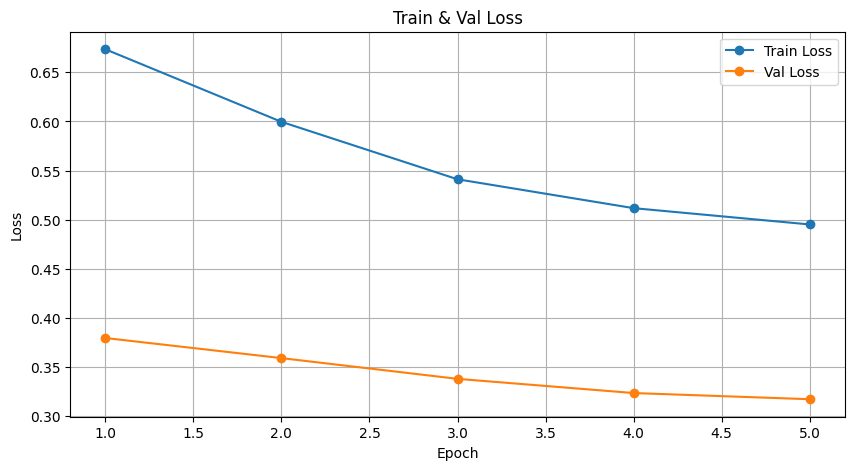

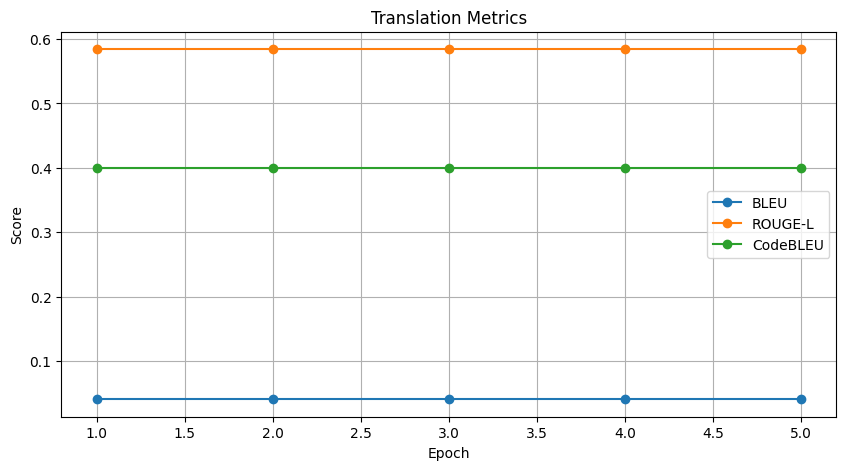

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, eval_loss, label="Val Loss", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train & Val Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, bleu_scores, label="BLEU", marker="o")
plt.plot(epochs, rouge_scores, label="ROUGE-L", marker="o")
plt.plot(epochs, codebleu_scores, label="CodeBLEU", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.title("Translation Metrics")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)

## STEP 11: Inference Example

In [ ]:
def translate_python_to_cpp(python_code):
    input_text = prefix + python_code
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model.generate(input_ids, max_length=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

example = """def multiply(a, b): return a * b"""
print("Python:", example)
translated_code = translate_python_to_cpp(example)
print("C++ Translation:", translated_code)

Python: def multiply(a, b): return a * b
C++ Translation: : return a * b


<ipython-input-14-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [ ]:
# # adding error manually -_-

# translated_code = "int multiply(int a, int b) { return a * b }"

## STEP 12: Inference with Attention (Corrected)

In [ ]:
# ... (Keep steps 0-10 as they are, including imports and model loading) ...

# Make sure you have loaded or trained the model before this step
# model_path = "codet5-python-cpp-finetuned"
# model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
# tokenizer = AutoTokenizer.from_pretrained(model_path)
# model.to("cuda" if torch.cuda.is_available() else "cpu") # Move model to GPU if available


def translate_and_get_attention_all_layers(python_code):
    input_text = prefix + python_code
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
    input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

    with torch.no_grad():
        device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
        with torch.amp.autocast(device_type=device_type, enabled=device_type=='cuda'):
            outputs = model.generate(
                input_ids,
                max_length=512,
                num_beams=1,
                output_attentions=True,
                return_dict_in_generate=True
            )

    output_ids = outputs.sequences[0]
    output_tokens = tokenizer.convert_ids_to_tokens(output_ids.tolist())
    decoded_output = tokenizer.decode(output_ids, skip_special_tokens=True)

    cross_attentions = outputs.cross_attentions
    if not cross_attentions:
        print("Warning: No cross attention found.")
        return decoded_output, input_tokens, output_tokens, None

    # Extract (num_layers, batch=1, num_heads, tgt_len, src_len)
    attentions_per_layer = []
    for layer in cross_attentions:
        if isinstance(layer, tuple):  # In case of tuple wrapping
            layer_tensor = layer[0]
        else:
            layer_tensor = layer
        attentions_per_layer.append(layer_tensor.squeeze(0))  # shape: (num_heads, tgt_len, src_len)

    return decoded_output, input_tokens, output_tokens, attentions_per_layer

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_avg_attention_all_layers(input_tokens, output_tokens, attentions_per_layer):
    if attentions_per_layer is None:
        print("No attention data to plot.")
        return

    for i, layer_attn in enumerate(attentions_per_layer):
        avg_attn = layer_attn.mean(dim=0).cpu().numpy()  # shape: (tgt_len, src_len)

        # Trim tokens
        try:
            out_end = output_tokens.index('</s>') + 1
        except ValueError:
            out_end = len(output_tokens)

        try:
            in_end = input_tokens.index('</s>') + 1
        except ValueError:
            in_end = len(input_tokens)

        out_tokens_trim = output_tokens[:out_end]
        in_tokens_trim = input_tokens[:in_end]
        attn_trimmed = avg_attn[:out_end, :in_end]

        # Create plot for each layer with 2 plots per row
        plt.figure(figsize=(8, 6))
        sns.heatmap(attn_trimmed, xticklabels=in_tokens_trim, yticklabels=out_tokens_trim, cmap="viridis")
        plt.title(f"Average Attention - Layer {i+1}")
        plt.xlabel("Input Tokens")
        plt.ylabel("Output Tokens")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


def plot_all_heads_last_layer(input_tokens, output_tokens, attentions_per_layer):
    last_layer = attentions_per_layer[-1]  # shape: (num_heads, tgt_len, src_len)
    num_heads = last_layer.shape[0]

    for h in range(num_heads):
        attn = last_layer[h].cpu().numpy()

        # Trim tokens
        try:
            out_end = output_tokens.index('</s>') + 1
        except ValueError:
            out_end = len(output_tokens)

        try:
            in_end = input_tokens.index('</s>') + 1
        except ValueError:
            in_end = len(input_tokens)

        # Create plot for each head with 2 per row (done by individual figure calls)
        plt.figure(figsize=(8, 6))
        sns.heatmap(attn[:out_end, :in_end],
                    xticklabels=input_tokens[:in_end],
                    yticklabels=output_tokens[:out_end],
                    cmap="viridis")
        plt.title(f"Head {h} - Last Layer")
        plt.xlabel("Input Tokens")
        plt.ylabel("Output Tokens")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


In [ ]:
decoded_output, input_tokens, output_tokens, attentions_per_layer = translate_and_get_attention_all_layers(example)
print(decoded_output)

: return a * b


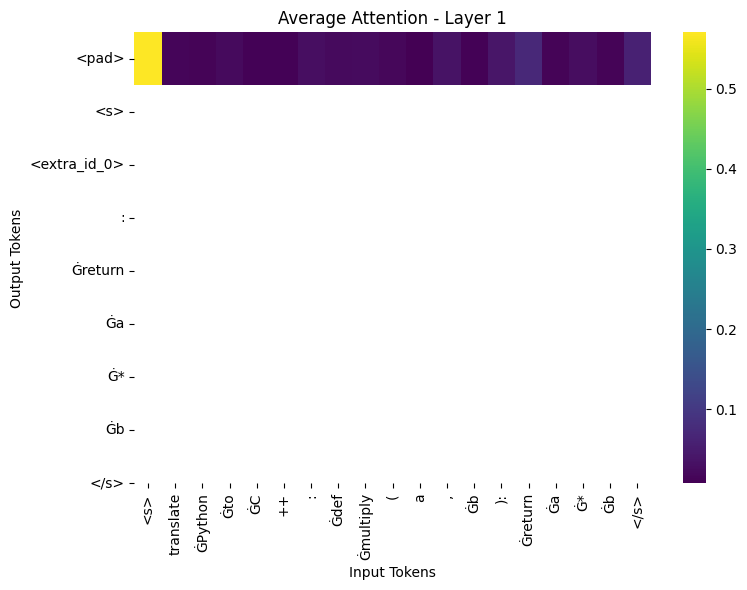

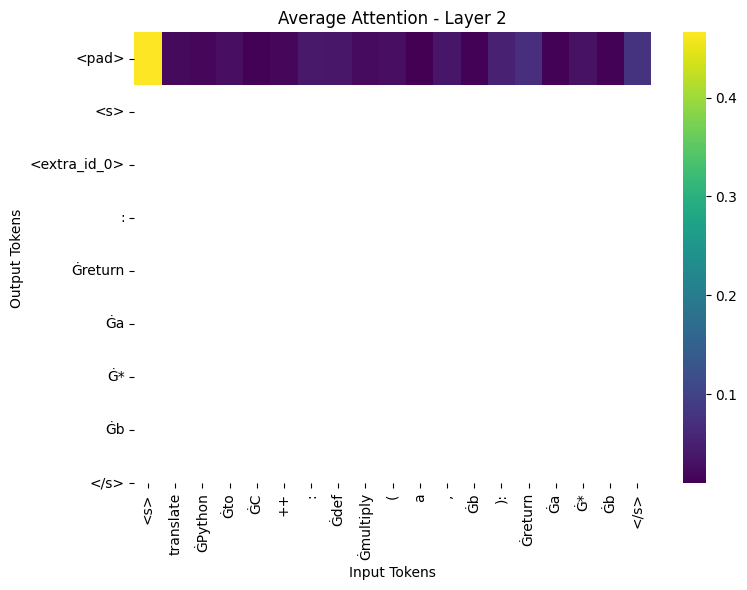

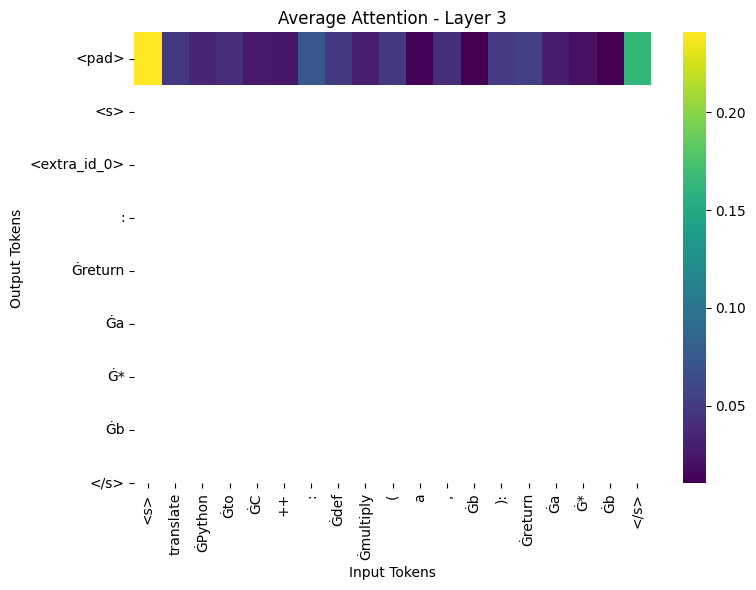

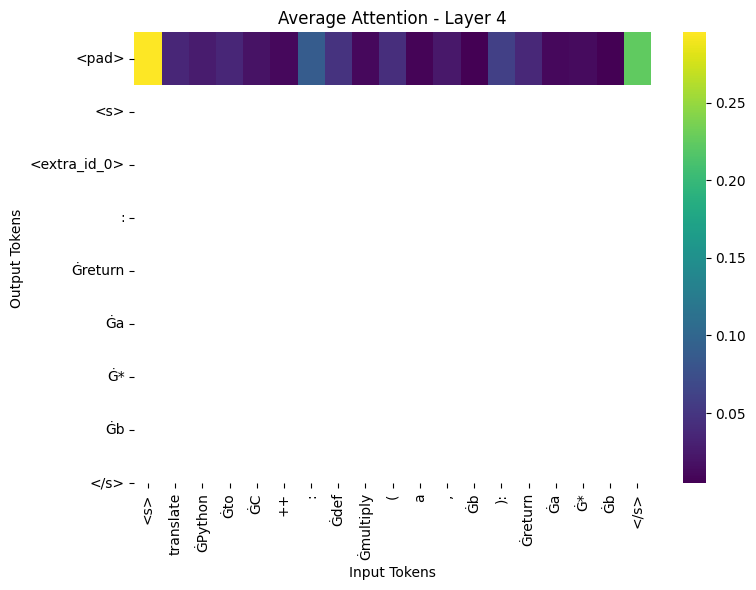

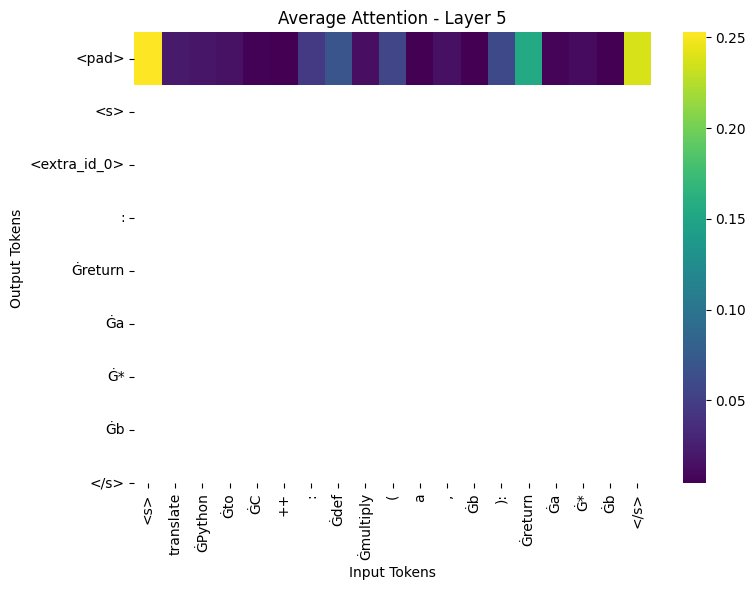

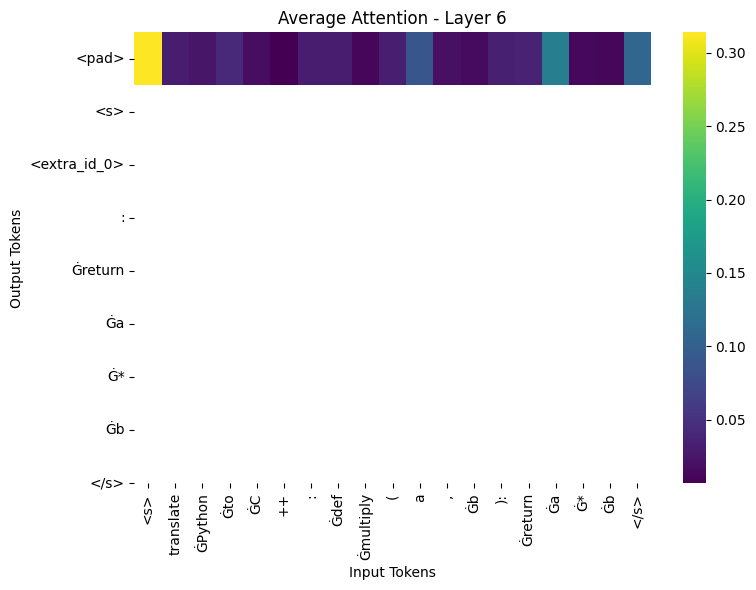

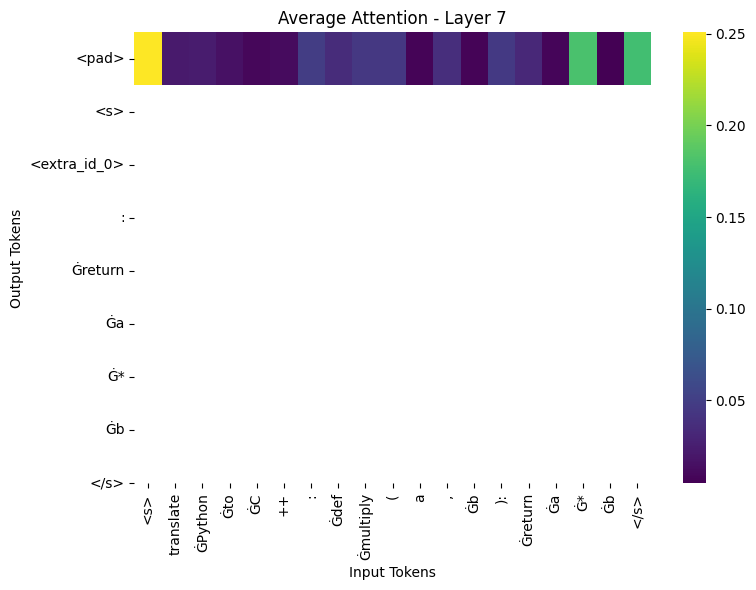

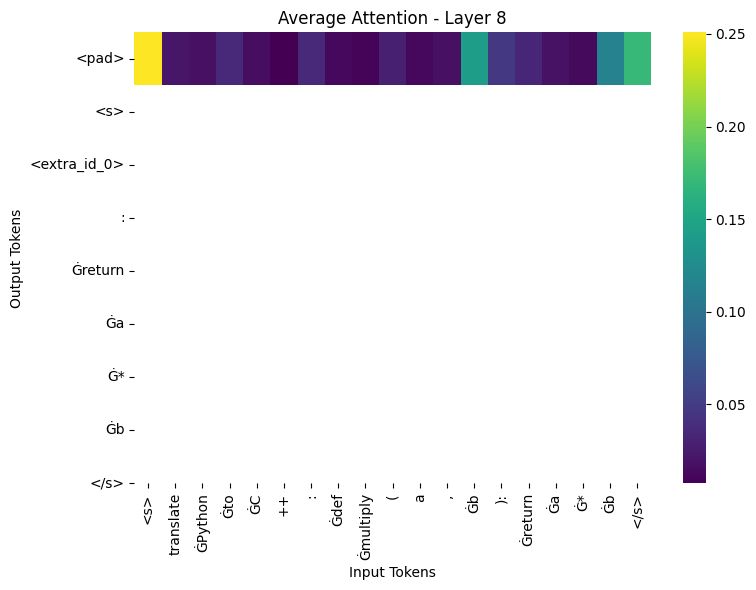

In [ ]:
plot_avg_attention_all_layers(input_tokens, output_tokens, attentions_per_layer)  # Averaged across heads

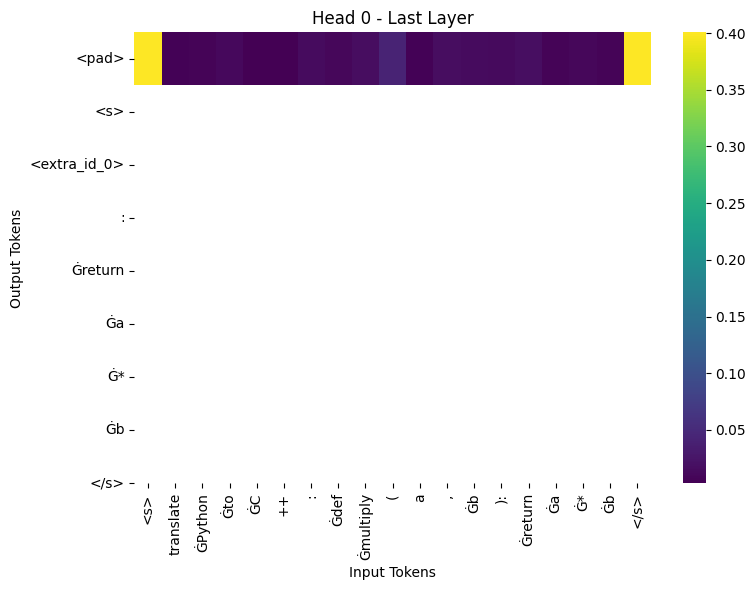

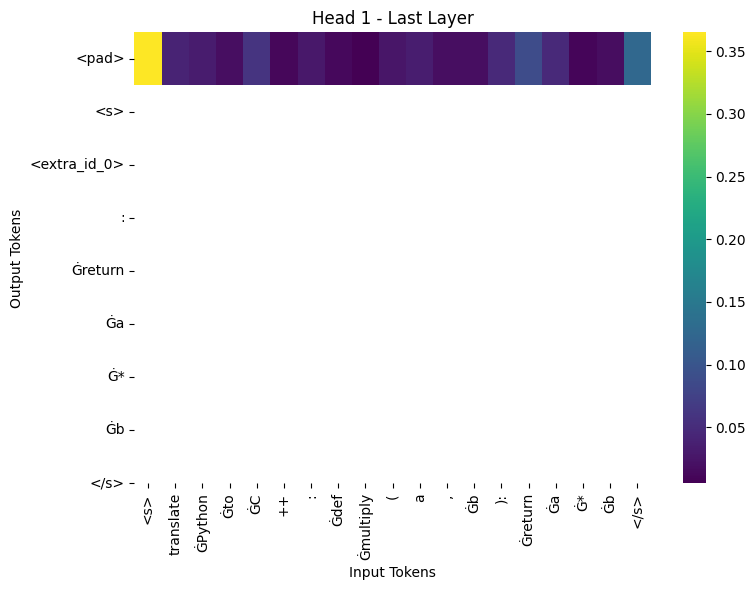

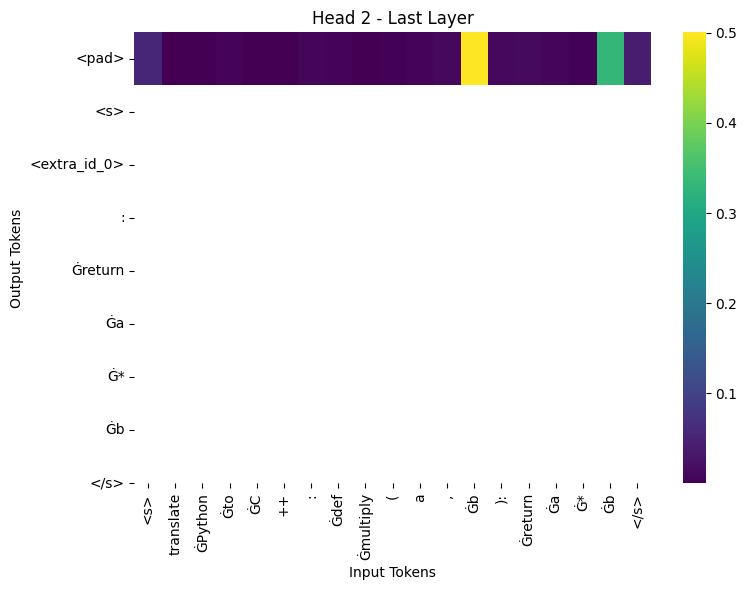

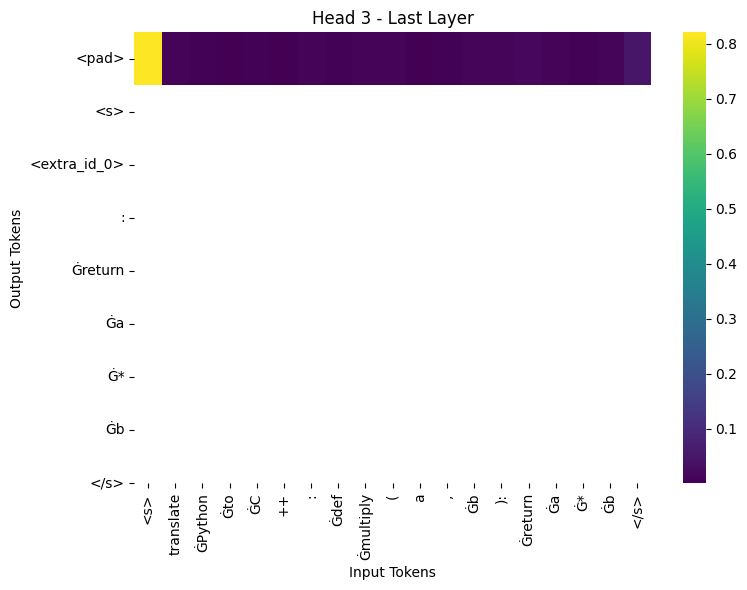

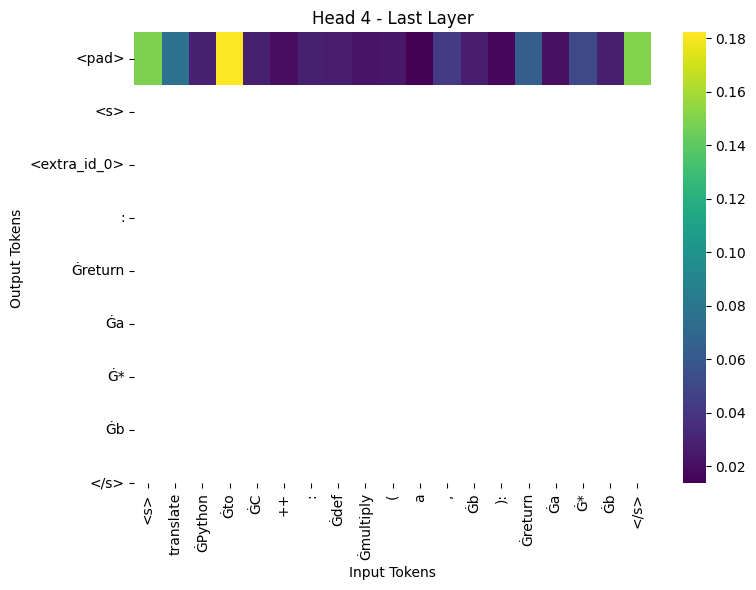

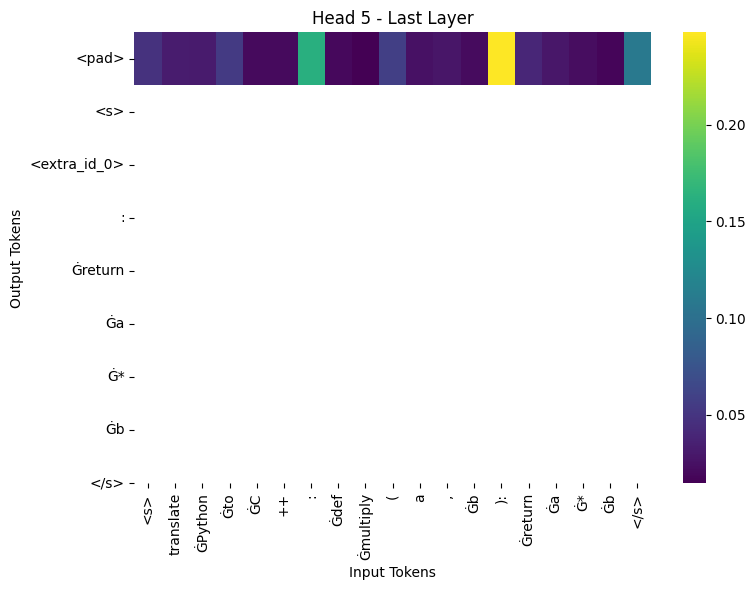

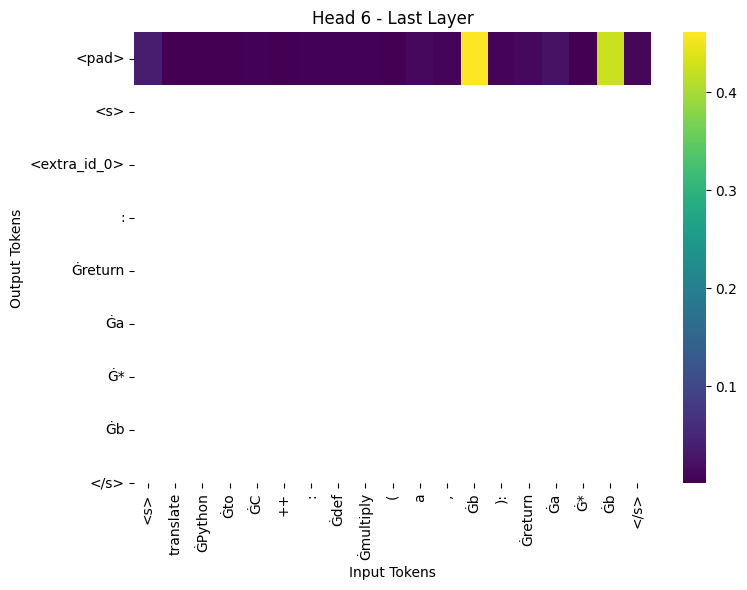

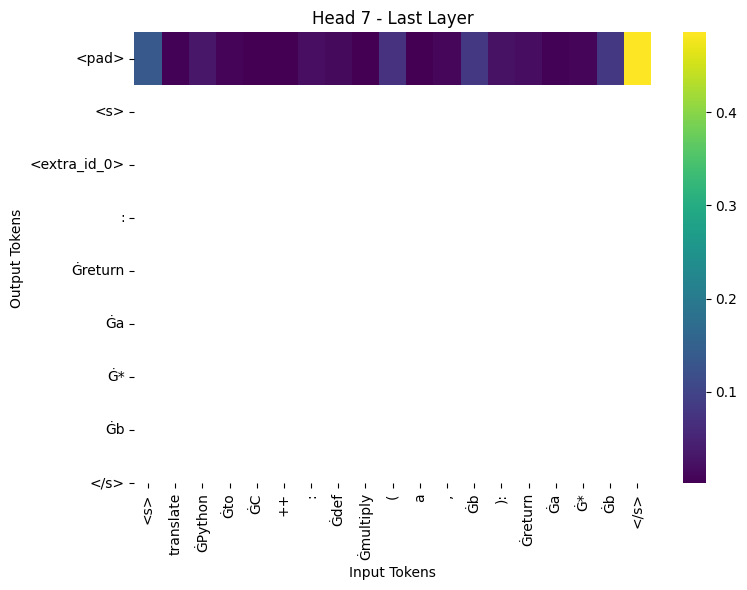

In [ ]:
plot_all_heads_last_layer(input_tokens, output_tokens, attentions_per_layer)   # Optional: Uncomment to view heads

## STEP 13: Error detection(gpp)

In [ ]:
import subprocess

def analyze_with_gpp(cpp_code: str) -> list[dict]:
    """
    Compiles the C++ code using g++ and captures error messages.

    Args:
        cpp_code: The C++ code string.

    Returns:
        A list of dictionaries, each representing a compiler error or warning.
    """
    # Save the code to a temporary file
    with open("./temp_code.cpp", "w") as f:
        f.write(cpp_code)

    # Compile using g++
    # - Wall: Enable all standard warnings
    # - Wextra: Enable extra warnings
    # - std=c++17: Specify C++ standard
    # - fsyntax-only: Only perform a syntax check, do not generate object file
    process = subprocess.Popen(
        ["g++", "temp_code.cpp", "-Wall", "-Wextra", "-std=c++17", "-fsyntax-only"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    a, stderr = process.communicate()

    errors = []
    # Parse the stderr output to extract error information
    # The exact parsing will depend on the format of g++ error messages,
    # but they typically include filename, line number, and error message.

    for line in stderr.decode().splitlines():
        if ": error:" in line or ": warning:" in line:
            try:
                parts = line.split(":")
                if len(parts) >= 4:
                    # Adjust parsing based on actual g++ output format
                    file = parts[0]
                    line_num = int(parts[1])
                    type = parts[2].strip() # 'error' or 'warning'
                    message = ":".join(parts[3:]).strip()
                    errors.append({'type': type, 'line': line_num, 'message': message})
            except (ValueError, IndexError):
                # Handle cases where the line doesn't match the expected format
                print(f"Could not parse error line: {line}")
                continue

    # Clean up the temporary file
    os.remove("temp_code.cpp")

    if errors != []:
      print("+++++++++++++ ERRORS FOUND +++++++++++")
      print(errors)
    else:
      print("+++++++++++++ NO ERRORS FOUND +++++++++")

    return errors

def postprocess_cpp_code_with_gpp(generated_cpp_code: str) -> (str, list[dict]):
    """
    Analyzes the generated C++ code using g++ feedback.
    For now, it only detects errors and doesn't perform automatic correction.
    """
    errors = analyze_with_gpp(generated_cpp_code)
    return generated_cpp_code, errors # Return original code and detected errors


In [ ]:
postprocess_cpp_code_with_gpp(translated_code)

+++++++++++++ ERRORS FOUND +++++++++++
[{'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}]


('int multiply(int a, int b) { return a * b }',
 [{'type': '42',
   'line': 1,
   'message': 'error: expected ‘;’ before ‘}’ token'}])

In [ ]:
import re

def postprocess_cpp_code_with_basic_correction(generated_cpp_code: str) -> (str, list[dict]):
    """
    Analyzes and attempts basic corrections on the generated C++ code using g++ feedback.
    """
    errors = analyze_with_gpp(generated_cpp_code)
    corrected_code = generated_cpp_code
    lines = corrected_code.splitlines()

    for error in errors:
        print("Each error : ", error)
        normalized_message = error['message'].replace('‘', "'").replace('’', "'")
        if "expected ';' before" in normalized_message and error['line'] > 0:
            print(" +++ semicolon error found +++ ")
            line_index = error['line'] - 1
            if line_index < len(lines):
                original_line = lines[line_index]
                # Match inline function with return
                match = re.match(r"(.*\{.*return\s+[^;{}]+)(\s*\})", original_line)
                if match:
                    # Add semicolon before closing brace
                    lines[line_index] = match.group(1).rstrip() + ';' + match.group(2)
                    print(f"Fixed inline return semicolon in function on line {error['line']}")
                else:
                    # Fallback: naive semicolon append
                    stripped_line = original_line.rstrip()
                    if not stripped_line.endswith((';', '}', '{', ':')):
                        lines[line_index] += ';'
                        print(f"Attempted naive correction: Added semicolon on line {error['line']}")

    corrected_code = "\n".join(lines)
    print("======= tried to correct ======== ")
    print(corrected_code)
    remaining_errors = analyze_with_gpp(corrected_code)

    return corrected_code, remaining_errors

In [ ]:
postprocess_cpp_code_with_basic_correction(translated_code)

+++++++++++++ ERRORS FOUND +++++++++++
[{'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}]
Each error :  {'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}
 +++ semicolon error found +++ 
Fixed inline return semicolon in function on line 1
======= tried to correct ======== 
int multiply(int a, int b) { return a * b;}
+++++++++++++ NO ERRORS FOUND +++++++++


('int multiply(int a, int b) { return a * b;}', [])

In [ ]:
def analyze_with_gpp(cpp_code: str) -> list[dict]:
    """
    Compiles the C++ code using g++ and captures and categorizes error messages.
    """
    with open("./temp_code.cpp", "w") as f:
        f.write(cpp_code)

    process = subprocess.Popen(
        ["g++", "temp_code.cpp", "-Wall", "-Wextra", "-std=c++17", "-fsyntax-only"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    _, stderr = process.communicate()
    os.remove("temp_code.cpp")

    errors = []
    for line in stderr.decode().splitlines():
        if ": error:" in line or ": warning:" in line:
            try:
                parts = line.split(":")
                if len(parts) >= 4:
                    file = parts[0]
                    line_num = int(parts[1])
                    type = parts[2].strip()
                    message = ":".join(parts[3:]).strip()

                    category = "OtherError"  # Default category

                    if re.search(r"expected ';' before", message):
                        category = "SemicolonError"
                    elif re.search(r"expected ‘\}' before", message) or re.search(r"expected ‘\{' at end of input", message) or re.search(r"mismatched ‘\(’", message) or re.search(r"mismatched ‘\[’", message):
                        category = "BracketError"
                    elif re.search(r"‘[a-zA-Z_]\w*’ was not declared in this scope", message) or re.search(r"undeclared identifier", message):
                        category = "DeclarationError"
                    elif re.search(r"cannot convert ‘.*’ to ‘.*’ in assignment", message) or re.search(r"invalid conversion from ‘.*’ to ‘.*’", message):
                        category = "TypeError"
                    elif re.search(r"expected ‘;’ at end of declaration", message):
                        category = "SyntaxError"
                    elif re.search(r"‘.*’ does not name a type", message):
                        category = "TypeNameError"  # New category
                    elif re.search(r"expected unqualified-id before ‘return’", message):
                        category = "ReturnError"  # New category
                    elif re.search(r"expected declaration before ‘\}’ token", message):
                        category = "ScopeError"  # New category

                    errors.append({
                        'type': type,
                        'line': line_num,
                        'message': message,
                        'category': category
                    })
            except (ValueError, IndexError):
                print(f"Could not parse error line: {line}")

    return errors


def translate_and_analyze(python_code):
    """
    Translates Python to C++ and analyzes the generated code for errors.
    """
    cpp_code = translate_python_to_cpp(python_code)  # Use your translation function
    errors = analyze_with_gpp(cpp_code)
    return cpp_code, errors

In [ ]:
# Example Usage and Error Analysis
# python_code_examples = [
#     "def add(a, b): return a + b",
#     "def subtract(a, b): return a - b",
#     "def my_func(x):\n  if x > 10: return x * 2",
#     "def process_data(data):\n  temp = data * 5\n  return temp",
#     "def get_value(my_dict, key):\n  return my_dict[key]"
# ]

# Read ALL Python codes from your CSV
python_code_examples = df["python_file"].tolist()

In [ ]:
from collections import defaultdict

<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: Futur


--- Error Counts: ---


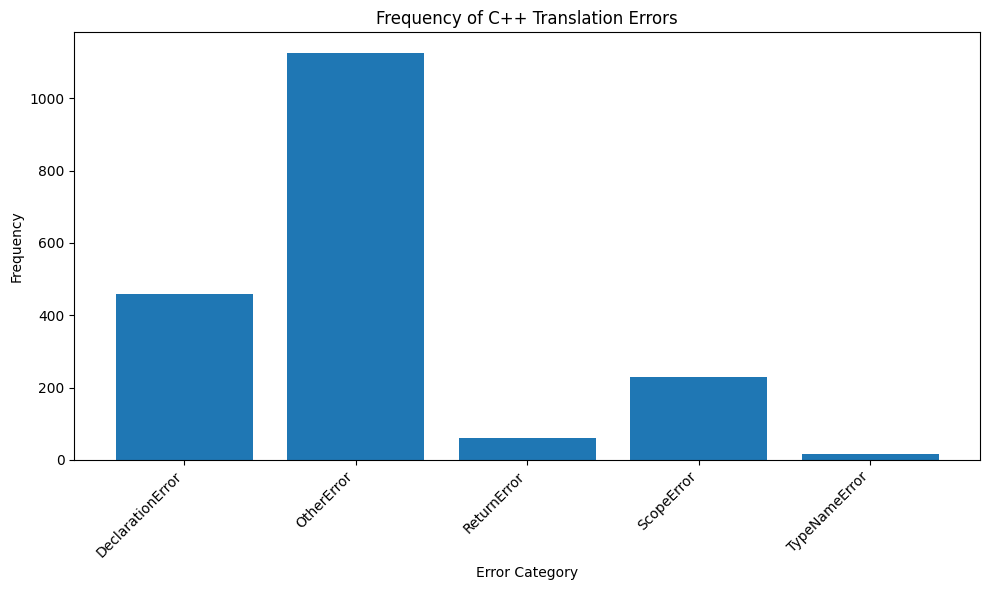

In [ ]:
all_errors = []
for python_code in python_code_examples:
    # print(f"\n--- Python Code: ---\n{python_code}")
    cpp_code, errors = translate_and_analyze(python_code)
    # print(f"\n--- C++ Code: ---\n{cpp_code}")
    if errors:
        all_errors.extend(errors)

# Error Frequency Calculation and Plotting
error_counts = defaultdict(int)
for error in all_errors:
    error_counts[error['category']] += 1

print("\n--- Error Counts: ---")

# Plotting
if error_counts:
    categories = list(error_counts.keys())
    counts = list(error_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(categories, counts)
    plt.xlabel("Error Category")
    plt.ylabel("Frequency")
    plt.title("Frequency of C++ Translation Errors")
    plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
    plt.tight_layout()
    plt.show()
else:
    print("No errors to plot.")